In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [25]:
print(os.listdir("/kaggle/input/datasets/navyyaa/train-static-csv"))

['train_static.csv']


In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# Load static CSV
df = pd.read_csv("/kaggle/input/datasets/navyyaa/train-static-csv/train_static.csv")

print("Total samples:", len(df))
print("Number of unique signs:", df["sign"].nunique())
print("\nClass distribution:")
print(df["sign"].value_counts().head(10))
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# Load static CSV
df = pd.read_csv("/kaggle/input/datasets/navyyaa/train-static-csv/train_static.csv")

print("Total samples:", len(df))
print("Number of unique signs:", df["sign"].nunique())
print("\nClass distribution:")
print(df["sign"].value_counts().head(10))


Total samples: 47446
Number of unique signs: 125

Class distribution:
sign
listen    415
shhh      411
donkey    410
mouse     408
uncle     405
hear      405
duck      405
bird      404
cow       404
brown     403
Name: count, dtype: int64
Total samples: 47446
Number of unique signs: 125

Class distribution:
sign
listen    415
shhh      411
donkey    410
mouse     408
uncle     405
hear      405
duck      405
bird      404
cow       404
brown     403
Name: count, dtype: int64


In [2]:
print(df.columns)

Index(['path', 'participant_id', 'sequence_id', 'sign', 'motion_score',
       'motion_category'],
      dtype='object')


In [3]:
import os
import pyarrow.parquet as pq
import numpy as np
from tqdm import tqdm

BASE_PATH = "/kaggle/input/competitions/asl-signs"

frame_counts = []
landmark_counts = []
nan_counts = []

sample_columns = None

for rel_path in tqdm(df["path"].values):
    
    full_path = os.path.join(BASE_PATH, rel_path)
    
    if not os.path.exists(full_path):
        continue
        
    table = pq.read_table(full_path)
    data = table.to_pandas()
    
    if sample_columns is None:
        sample_columns = data.columns.tolist()
    
    frame_counts.append(data["frame"].nunique())
    landmark_counts.append(data["landmark_index"].nunique())
    nan_counts.append(data.isna().sum().sum())

print("\n---- Sequence Statistics ----")
print("Min frames:", np.min(frame_counts))
print("Max frames:", np.max(frame_counts))
print("Mean frames:", np.mean(frame_counts))

print("\nLandmarks per frame (unique indices):")
print("Min:", np.min(landmark_counts))
print("Max:", np.max(landmark_counts))

print("\nTotal NaN values across dataset:", np.sum(nan_counts))

print("\nColumn structure:")
print(sample_columns)



100%|██████████| 47446/47446 [21:28<00:00, 36.83it/s]  


---- Sequence Statistics ----
Min frames: 2
Max frames: 537
Mean frames: 38.515428065590356

Landmarks per frame (unique indices):
Min: 468
Max: 468

Total NaN values across dataset: 173247561

Column structure:
['frame', 'row_id', 'type', 'landmark_index', 'x', 'y', 'z']


In [5]:
import pandas as pd
import numpy as np
import os
import pyarrow.parquet as pq

BASE_PATH = "/kaggle/input/competitions/asl-signs"  # adjust if needed

def process_sequence(rel_path):
    full_path = os.path.join(BASE_PATH, rel_path)
    data = pq.read_table(full_path).to_pandas()
    
    # Keep only hands
    data = data[data["type"].isin(["left_hand", "right_hand"])]
    
    # If nothing detected, return None
    if len(data) == 0:
        return None
    
    # Pivot to structured array
    # (frame, landmark_index, xyz)
    data = data.sort_values(["frame", "landmark_index"])
    
    frames = data["frame"].unique()
    
    frame_features = []
    
    for f in frames:
        frame_data = data[data["frame"] == f]
        
        # 21 landmarks per hand → 42 total
        coords = frame_data[["x","y","z"]].values
        
        # Replace NaNs
        coords = np.nan_to_num(coords)
        
        # Normalize to wrist (landmark 0 for each hand)
        # Left hand wrist index = 0
        # Right hand wrist index = 21
        if len(coords) >= 42:
            left_wrist = coords[0]
            right_wrist = coords[21]
            
            coords[:21] -= left_wrist
            coords[21:42] -= right_wrist
        
        frame_features.append(coords.flatten())
    
    frame_features = np.array(frame_features)
    
    # Average across frames
    sequence_feature = frame_features.mean(axis=0)
    
    return sequence_feature


In [6]:
from tqdm import tqdm

X = []
y = []

label_map = {label: idx for idx, label in enumerate(df["sign"].unique())}

for _, row in tqdm(df.iterrows(), total=len(df)):
    feat = process_sequence(row["path"])
    
    if feat is not None:
        X.append(feat)
        y.append(label_map[row["sign"]])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)


100%|██████████| 47446/47446 [30:13<00:00, 26.17it/s]  

Feature shape: (47446, 126)


In [38]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Number of classes:", len(np.unique(y_train)))


Train shape: (37956, 126)
Val shape: (9490, 126)
Number of classes: 125


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


In [40]:
import torch
from torch.utils.data import Dataset, DataLoader

class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SignDataset(X_train, y_train)
val_dataset = SignDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)


In [41]:
import torch.nn as nn

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim, num_classes)


In [42]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)


In [43]:
from tqdm import tqdm
import torch

EPOCHS = 50
best_val_acc = 0

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    train_loss = 0
    correct = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()

    train_acc = correct / len(train_dataset)


    # ---- VALIDATE ----
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()

    val_acc = correct / len(val_dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


    # ---- SAVE BEST CHECKPOINT ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler': scaler,
            'label_map': label_map,
            'input_dim': input_dim,
            'num_classes': num_classes,
            'val_accuracy': val_acc
        }, "best_static_mlp_checkpoint.pth")

        print("✅ Checkpoint Saved!")

print("Training Complete!")


Epoch 1/50
Train Acc: 0.1853 | Val Acc: 0.3397
✅ Checkpoint Saved!
Epoch 2/50
Train Acc: 0.3242 | Val Acc: 0.4101
✅ Checkpoint Saved!
Epoch 3/50
Train Acc: 0.3656 | Val Acc: 0.4555
✅ Checkpoint Saved!
Epoch 4/50
Train Acc: 0.3965 | Val Acc: 0.4674
✅ Checkpoint Saved!
Epoch 5/50
Train Acc: 0.4190 | Val Acc: 0.4890
✅ Checkpoint Saved!
Epoch 6/50
Train Acc: 0.4342 | Val Acc: 0.5006
✅ Checkpoint Saved!
Epoch 7/50
Train Acc: 0.4451 | Val Acc: 0.5117
✅ Checkpoint Saved!
Epoch 8/50
Train Acc: 0.4550 | Val Acc: 0.5213
✅ Checkpoint Saved!
Epoch 9/50
Train Acc: 0.4649 | Val Acc: 0.5371
✅ Checkpoint Saved!
Epoch 10/50
Train Acc: 0.4725 | Val Acc: 0.5307
Epoch 11/50
Train Acc: 0.4794 | Val Acc: 0.5362
Epoch 12/50
Train Acc: 0.4836 | Val Acc: 0.5459
✅ Checkpoint Saved!
Epoch 13/50
Train Acc: 0.4889 | Val Acc: 0.5511
✅ Checkpoint Saved!
Epoch 14/50
Train Acc: 0.4949 | Val Acc: 0.5490
Epoch 15/50
Train Acc: 0.5057 | Val Acc: 0.5504
Epoch 16/50
Train Acc: 0.5000 | Val Acc: 0.5620
✅ Checkpoint Saved!
E

In [44]:
import numpy as np
import pyarrow.parquet as pq
import os


In [45]:
def compute_geometric_features(hand_landmarks):
    """
    hand_landmarks: (21, 3)
    returns 1D feature vector
    """

    wrist = hand_landmarks[0]

    # Fingertip indices in MediaPipe
    fingertips = [4, 8, 12, 16, 20]

    features = []

    # Distance from fingertips to wrist
    for tip in fingertips:
        dist = np.linalg.norm(hand_landmarks[tip] - wrist)
        features.append(dist)

    # Adjacent fingertip distances
    for i in range(len(fingertips) - 1):
        dist = np.linalg.norm(
            hand_landmarks[fingertips[i]] -
            hand_landmarks[fingertips[i+1]]
        )
        features.append(dist)

    return np.array(features)


In [53]:
BASE_PATH = "/kaggle/input/competitions/asl-signs"

sample_path = os.path.join(BASE_PATH, df.iloc[0]["path"])

table = pq.read_table(sample_path)
df_seq = table.to_pandas()

print(df_seq["type"].unique())


['face' 'left_hand' 'pose' 'right_hand']


In [54]:
BASE_PATH = "/kaggle/input/competitions/asl-signs"

In [7]:
import os
import numpy as np

os.makedirs("saved_data", exist_ok=True)

np.save("saved_data/X_static.npy", X)
np.save("saved_data/y_static.npy", y)

print("✅ Features Saved Successfully")

✅ Features Saved Successfully


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (37956, 126)
Val: (9490, 126)


In [10]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Save scaler for inference
os.makedirs("checkpoints", exist_ok=True)
joblib.dump(scaler, "checkpoints/static_scaler.pkl")

print("✅ Scaler saved")


✅ Scaler saved


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class StaticDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StaticDataset(X_train, y_train)
val_dataset = StaticDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)


In [12]:
import torch.nn as nn

class StaticSignModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train.shape[1]
num_classes = len(set(y))

model = StaticSignModel(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [18]:
import os

os.makedirs("checkpoints", exist_ok=True)

best_val_acc = 0

for epoch in range(50):
    # ----- TRAIN -----
    model.train()
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    train_acc = correct / total
    
    # ----- VALIDATION -----
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    val_acc = correct / total
    
    print(f"Epoch {epoch+1}/50")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/best_static_model.pth")
        print("✅ Checkpoint Saved")


Epoch 1/50
Train Acc: 0.1700 | Val Acc: 0.3099
✅ Checkpoint Saved
Epoch 2/50
Train Acc: 0.3016 | Val Acc: 0.3800
✅ Checkpoint Saved
Epoch 3/50
Train Acc: 0.3451 | Val Acc: 0.4188
✅ Checkpoint Saved
Epoch 4/50
Train Acc: 0.3761 | Val Acc: 0.4458
✅ Checkpoint Saved
Epoch 5/50
Train Acc: 0.3995 | Val Acc: 0.4588
✅ Checkpoint Saved
Epoch 6/50
Train Acc: 0.4164 | Val Acc: 0.4822
✅ Checkpoint Saved
Epoch 7/50
Train Acc: 0.4280 | Val Acc: 0.4954
✅ Checkpoint Saved
Epoch 8/50
Train Acc: 0.4389 | Val Acc: 0.5031
✅ Checkpoint Saved
Epoch 9/50
Train Acc: 0.4539 | Val Acc: 0.4969
Epoch 10/50
Train Acc: 0.4576 | Val Acc: 0.5126
✅ Checkpoint Saved
Epoch 11/50
Train Acc: 0.4648 | Val Acc: 0.5216
✅ Checkpoint Saved
Epoch 12/50
Train Acc: 0.4742 | Val Acc: 0.5302
✅ Checkpoint Saved
Epoch 13/50
Train Acc: 0.4789 | Val Acc: 0.5436
✅ Checkpoint Saved
Epoch 14/50
Train Acc: 0.4840 | Val Acc: 0.5426
Epoch 15/50
Train Acc: 0.4904 | Val Acc: 0.5454
✅ Checkpoint Saved
Epoch 16/50
Train Acc: 0.4985 | Val Acc: 0

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class StaticCNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        self.conv1 = nn.Conv1d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256 * input_dim, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,features)
        
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        x = x.flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StaticCNN(input_dim=X_train.shape[1], num_classes=len(label_map))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,   # number of epochs
    eta_min=1e-6
)


In [21]:
import os

os.makedirs("checkpoints", exist_ok=True)

best_val_acc = 0

for epoch in range(30):
    model.train()
    train_correct = 0
    train_total = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)
    
    train_acc = train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)
    
    val_acc = val_correct / val_total
    
    scheduler.step()
    
    print(f"Epoch {epoch+1}/30")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_acc": val_acc,
            "label_map": label_map,
            "input_dim": X_train.shape[1]
        }, "checkpoints/best_static_cnn.pth")
        
        print("✅ Checkpoint Saved")


Epoch 1/30
Train Acc: 0.2157 | Val Acc: 0.3358
✅ Checkpoint Saved
Epoch 2/30
Train Acc: 0.3758 | Val Acc: 0.4095
✅ Checkpoint Saved
Epoch 3/30
Train Acc: 0.4432 | Val Acc: 0.4446
✅ Checkpoint Saved
Epoch 4/30
Train Acc: 0.4838 | Val Acc: 0.4669
✅ Checkpoint Saved
Epoch 5/30
Train Acc: 0.5129 | Val Acc: 0.4893
✅ Checkpoint Saved
Epoch 6/30
Train Acc: 0.5376 | Val Acc: 0.5043
✅ Checkpoint Saved
Epoch 7/30
Train Acc: 0.5622 | Val Acc: 0.5200
✅ Checkpoint Saved
Epoch 8/30
Train Acc: 0.5796 | Val Acc: 0.5209
✅ Checkpoint Saved
Epoch 9/30
Train Acc: 0.6004 | Val Acc: 0.5351
✅ Checkpoint Saved
Epoch 10/30
Train Acc: 0.6188 | Val Acc: 0.5417
✅ Checkpoint Saved
Epoch 11/30
Train Acc: 0.6366 | Val Acc: 0.5495
✅ Checkpoint Saved
Epoch 12/30
Train Acc: 0.6568 | Val Acc: 0.5613
✅ Checkpoint Saved
Epoch 13/30
Train Acc: 0.6772 | Val Acc: 0.5585
Epoch 14/30
Train Acc: 0.6910 | Val Acc: 0.5662
✅ Checkpoint Saved
Epoch 15/30
Train Acc: 0.7092 | Val Acc: 0.5682
✅ Checkpoint Saved
Epoch 16/30
Train Acc: 

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x shape: (B, features)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x



In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleMLP(input_dim=X_train.shape[1], num_classes=len(label_map))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,   # number of epochs
    eta_min=1e-6
)


In [25]:
import os

os.makedirs("checkpoints", exist_ok=True)

best_val_acc = 0

for epoch in range(30):
    model.train()
    train_correct = 0
    train_total = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        outputs = model(xb)  # MLP expects (B, features)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)
    
    train_acc = train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)
    
    val_acc = val_correct / val_total
    
    scheduler.step()
    
    print(f"Epoch {epoch+1}/30")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_acc": val_acc,
            "label_map": label_map,
            "input_dim": X_train.shape[1]
        }, "checkpoints/best_mlp.pth")
        
        print("✅ Checkpoint Saved")



Epoch 1/30
Train Acc: 0.1379 | Val Acc: 0.2779
✅ Checkpoint Saved
Epoch 2/30
Train Acc: 0.2814 | Val Acc: 0.3638
✅ Checkpoint Saved
Epoch 3/30
Train Acc: 0.3337 | Val Acc: 0.4018
✅ Checkpoint Saved
Epoch 4/30
Train Acc: 0.3662 | Val Acc: 0.4409
✅ Checkpoint Saved
Epoch 5/30
Train Acc: 0.3918 | Val Acc: 0.4471
✅ Checkpoint Saved
Epoch 6/30
Train Acc: 0.4095 | Val Acc: 0.4635
✅ Checkpoint Saved
Epoch 7/30
Train Acc: 0.4249 | Val Acc: 0.4803
✅ Checkpoint Saved
Epoch 8/30
Train Acc: 0.4420 | Val Acc: 0.4823
✅ Checkpoint Saved
Epoch 9/30
Train Acc: 0.4523 | Val Acc: 0.5015
✅ Checkpoint Saved
Epoch 10/30
Train Acc: 0.4617 | Val Acc: 0.5091
✅ Checkpoint Saved
Epoch 11/30
Train Acc: 0.4756 | Val Acc: 0.5174
✅ Checkpoint Saved
Epoch 12/30
Train Acc: 0.4814 | Val Acc: 0.5263
✅ Checkpoint Saved
Epoch 13/30
Train Acc: 0.4889 | Val Acc: 0.5338
✅ Checkpoint Saved
Epoch 14/30
Train Acc: 0.4997 | Val Acc: 0.5404
✅ Checkpoint Saved
Epoch 15/30
Train Acc: 0.5033 | Val Acc: 0.5456
✅ Checkpoint Saved
Epoc

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import numpy as np


In [27]:
# Put model in eval mode if you want to use learned features (optional)
model.eval()

# Use a subset if dataset is huge
X_vis = X_train[:1000] if X_train.shape[0] > 1000 else X_train
y_vis = y_train[:1000] if X_train.shape[0] > 1000 else y_train

# Convert to numpy if they are torch tensors
if isinstance(X_vis, torch.Tensor):
    X_vis = X_vis.cpu().numpy()
if isinstance(y_vis, torch.Tensor):
    y_vis = y_vis.cpu().numpy()


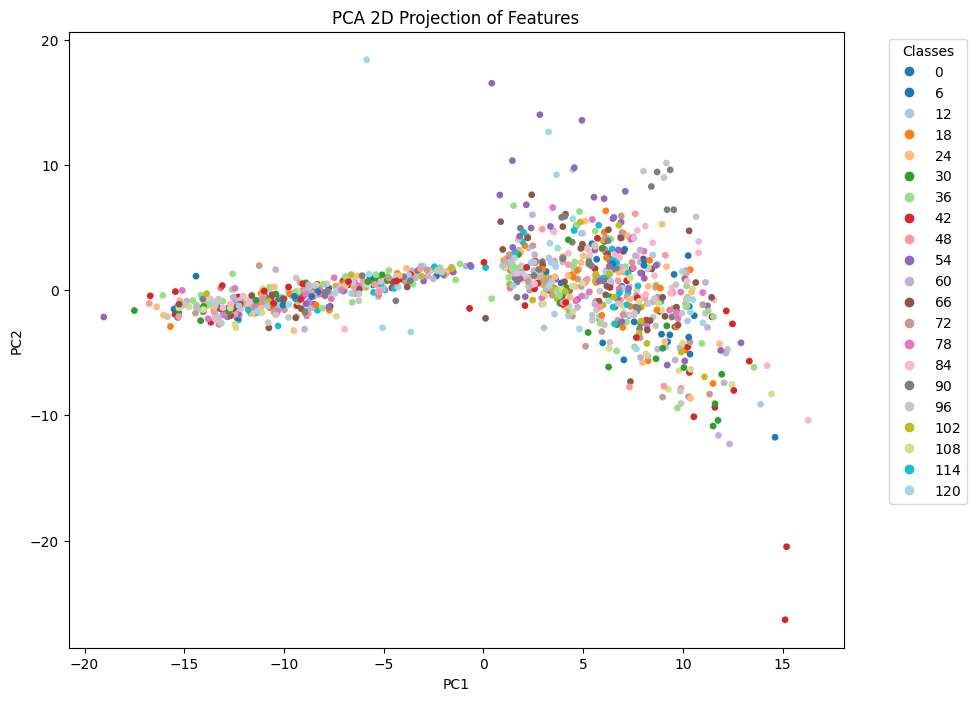

In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_vis, cmap='tab20', s=15)
plt.legend(*scatter.legend_elements(num=20), title="Classes", bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("PCA 2D Projection of Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


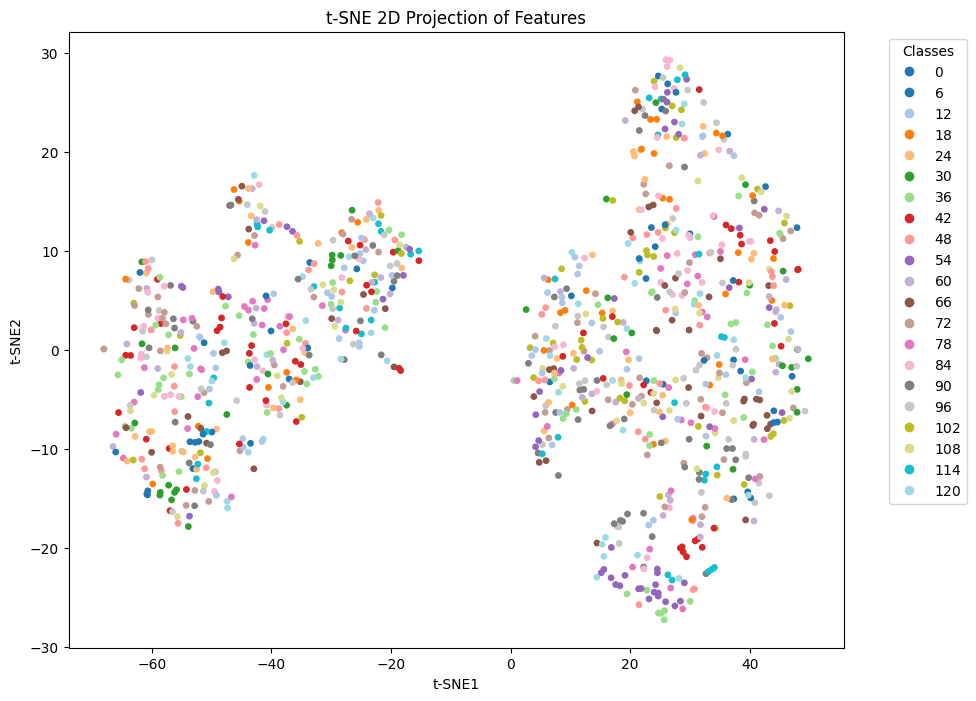

In [29]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_vis, cmap='tab20', s=15)
plt.legend(*scatter.legend_elements(num=20), title="Classes", bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("t-SNE 2D Projection of Features")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.show()


In [69]:
from collections import Counter
Counter(y_train)


Counter({np.int64(7): 10,
         np.int64(123): 10,
         np.int64(76): 14,
         np.int64(27): 11,
         np.int64(98): 13,
         np.int64(108): 11,
         np.int64(38): 14,
         np.int64(15): 20,
         np.int64(60): 16,
         np.int64(36): 6,
         np.int64(118): 16,
         np.int64(19): 10,
         np.int64(21): 11,
         np.int64(110): 15,
         np.int64(120): 12,
         np.int64(12): 9,
         np.int64(70): 14,
         np.int64(99): 9,
         np.int64(63): 15,
         np.int64(10): 13,
         np.int64(94): 14,
         np.int64(64): 11,
         np.int64(4): 13,
         np.int64(82): 12,
         np.int64(100): 12,
         np.int64(11): 10,
         np.int64(88): 8,
         np.int64(103): 7,
         np.int64(34): 10,
         np.int64(29): 13,
         np.int64(121): 14,
         np.int64(54): 15,
         np.int64(55): 10,
         np.int64(106): 12,
         np.int64(49): 8,
         np.int64(114): 14,
         np.int64(68): 12,

In [72]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import pyarrow.parquet as pq

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


In [74]:
BASE_PATH = "/kaggle/input/competitions/asl-signs"

NUM_FRAMES = 5   # use 5 frames per sample

def process_sequence_multi(path):
    
    full_path = os.path.join(BASE_PATH, path)
    if not os.path.exists(full_path):
        return None
    
    table = pq.read_table(full_path)
    df_seq = table.to_pandas()
    
    # Keep only hands
    df_seq = df_seq[df_seq["type"].isin(["left_hand", "right_hand"])]
    
    if df_seq.empty:
        return None
    
    frames = sorted(df_seq["frame"].unique())
    
    if len(frames) < NUM_FRAMES:
        return None
    
    # Pick evenly spaced frames
    selected_frames = np.linspace(0, len(frames)-1, NUM_FRAMES, dtype=int)
    selected_frames = [frames[i] for i in selected_frames]
    
    feature_list = []
    
    for frame in selected_frames:
        frame_data = df_seq[df_seq["frame"] == frame]
        
        # sort landmarks for consistency
        frame_data = frame_data.sort_values("landmark_index")
        
        coords = frame_data[["x", "y", "z"]].values
        
        if coords.shape[0] != 468:   # 21 left + 21 right = 42 per hand? 
            # if missing landmarks, skip
            return None
        
        # Normalize to wrist (landmark 0 of each hand)
        wrist = coords[0]
        coords = coords - wrist
        
        feature_list.append(coords.flatten())
    
    return np.concatenate(feature_list)


In [76]:
import numpy as np

X = np.load("saved_data/X_static.npy")
y = np.load("saved_data/y_static.npy")

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)


Feature shape: (47446, 126)
Labels shape: (47446,)


In [82]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Save scaler stats
os.makedirs("checkpoints_static", exist_ok=True)
np.save("checkpoints_static/scaler_mean.npy", scaler.mean_)
np.save("checkpoints_static/scaler_scale.npy", scaler.scale_)


In [83]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [90]:
class ASLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [93]:
train_dataset = ASLDataset(X_train, y_train)
val_dataset = ASLDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)


In [94]:
class StaticClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StaticClassifier(
    input_dim=X.shape[1],
    num_classes=125
).to(device)


In [97]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)


In [98]:
num_epochs = 50
best_val_acc = 0

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # -------- SAVE BEST MODEL --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_acc": val_acc
        }, "checkpoints_static/best_static_model.pth")

        print("✅ Best model saved!")

print("Training Complete")


Epoch 1/50
Train Acc: 0.0970 | Val Acc: 0.2407
✅ Best model saved!
Epoch 2/50
Train Acc: 0.2270 | Val Acc: 0.3512
✅ Best model saved!
Epoch 3/50
Train Acc: 0.2925 | Val Acc: 0.3920
✅ Best model saved!
Epoch 4/50
Train Acc: 0.3266 | Val Acc: 0.4193
✅ Best model saved!
Epoch 5/50
Train Acc: 0.3526 | Val Acc: 0.4477
✅ Best model saved!
Epoch 6/50
Train Acc: 0.3708 | Val Acc: 0.4674
✅ Best model saved!
Epoch 7/50
Train Acc: 0.3839 | Val Acc: 0.4828
✅ Best model saved!
Epoch 8/50
Train Acc: 0.4000 | Val Acc: 0.4904
✅ Best model saved!
Epoch 9/50
Train Acc: 0.4135 | Val Acc: 0.5038
✅ Best model saved!
Epoch 10/50
Train Acc: 0.4227 | Val Acc: 0.5081
✅ Best model saved!
Epoch 11/50
Train Acc: 0.4347 | Val Acc: 0.5215
✅ Best model saved!
Epoch 12/50
Train Acc: 0.4392 | Val Acc: 0.5275
✅ Best model saved!
Epoch 13/50
Train Acc: 0.4499 | Val Acc: 0.5264
Epoch 14/50
Train Acc: 0.4533 | Val Acc: 0.5314
✅ Best model saved!
Epoch 15/50
Train Acc: 0.4611 | Val Acc: 0.5389
✅ Best model saved!
Epoch 16/

In [103]:
import pyarrow.parquet as pq
import numpy as np
import os
from tqdm import tqdm

BASE_PATH = "/kaggle/input/competitions/asl-signs"

MAX_FRAMES = 16
NUM_JOINTS = 42  # 21 left + 21 right

X_seq = []
y_seq = []

label_map = {label: idx for idx, label in enumerate(df["sign"].unique())}

def process_sequence_temporal(path):

    table = pq.read_table(path)
    data = table.to_pandas()

    data = data[data["type"].isin(["left_hand", "right_hand"])]

    if len(data) == 0:
        return None

    frames = sorted(data["frame"].unique())

    # Sample frames evenly
    if len(frames) > MAX_FRAMES:
        idx = np.linspace(0, len(frames)-1, MAX_FRAMES).astype(int)
        frames = np.array(frames)[idx]

    sequence = []

    for f in frames:
        frame_data = data[data["frame"] == f]

        left = frame_data[frame_data["type"] == "left_hand"]
        right = frame_data[frame_data["type"] == "right_hand"]

        if len(left) != 21 or len(right) != 21:
            return None

        left_xyz = left.sort_values("landmark_index")[["x","y","z"]].values
        right_xyz = right.sort_values("landmark_index")[["x","y","z"]].values

        # Normalize to wrist
        left_xyz -= left_xyz[0]
        right_xyz -= right_xyz[0]
g
        frame_tensor = np.vstack([left_xyz, right_xyz])  # (42,3)
        sequence.append(frame_tensor)

    if len(sequence) == 0:
        return None

    sequence = np.array(sequence)

    # Pad if needed
    if sequence.shape[0] < MAX_FRAMES:
        pad = np.zeros((MAX_FRAMES - sequence.shape[0], 42, 3))
        sequence = np.vstack([sequence, pad])

    return sequence


In [104]:
for _, row in tqdm(df.iterrows(), total=len(df)):

    full_path = os.path.join(BASE_PATH, row["path"])
    seq = process_sequence_temporal(full_path)

    if seq is not None:
        X_seq.append(seq)
        y_seq.append(label_map[row["sign"]])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Temporal Feature Shape:", X_seq.shape)


100%|██████████| 47446/47446 [33:46<00:00, 23.41it/s]


Temporal Feature Shape: (47446, 16, 42, 3)


In [105]:
os.makedirs("saved_data", exist_ok=True)

np.save("saved_data/X_seq.npy", X_seq)
np.save("saved_data/y_seq.npy", y_seq)

print("✅ Temporal data saved")




✅ Temporal data saved


In [126]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)


Train shape: (37956, 16, 42, 3)
Val shape: (9490, 16, 42, 3)


In [128]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)


/tmp/ipykernel_55/190942602.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_55/190942602.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val   = torch.tensor(X_val, dtype=torch.float32)
/tmp/ipykernel_55/190942602.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_55/190942602.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor

In [129]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Train loader batches:", len(train_loader))


Train loader batches: 594


In [130]:
for xb, yb in train_loader:
    print("Batch shape:", xb.shape)
    break


Batch shape: torch.Size([64, 16, 42, 3])


In [132]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GraphTemporalCNN(nn.Module):
    def __init__(self, num_joints=42, in_channels=3, num_classes=125):
        super().__init__()

        self.input_channels = num_joints * in_channels

        # Spatial projection
        self.spatial_fc = nn.Linear(self.input_channels, 256)

        # Temporal CNN
        self.conv1 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)

        self.conv2 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)

        self.conv3 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(512)

        self.dropout = nn.Dropout(0.4)

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # x: (B, T, J, C)

        B, T, J, C = x.shape
        x = x.view(B, T, J*C)

        # Spatial mixing
        x = self.spatial_fc(x)
        x = F.relu(x)

        # Convert to (B, Channels, T)
        x = x.permute(0, 2, 1)

        # Temporal Conv blocks
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x)))

        # Global temporal pooling
        x = torch.mean(x, dim=2)

        x = self.fc(x)
        return x


In [134]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphTemporalCNN(
    num_joints=42,
    in_channels=3,
    num_classes=len(label_map)
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50,
    eta_min=1e-6
)


In [140]:
print(model)


GraphTemporalCNN(
  (spatial_fc): Linear(in_features=126, out_features=256, bias=True)
  (conv1): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=125, bias=True)
)
